# NeuroDetect — Brain Tumor Detection
**Course**: Computer Vision | Christian Mata, PhD

**Dataset**: LGG Brain MRI Segmentation (Kaggle — mateuszbuda)

**Task**: Setup: Download and Prepare Dataset

**Group members**: Martin Çaro, Edison Zyberaj

# Setup: Download and Prepare Dataset
Mounts Drive, downloads from Kaggle, converts TIF files to PNG.


## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE = '/content/drive/MyDrive/CV_Project'
os.makedirs(DRIVE + '/brain/images', exist_ok=True)
os.makedirs(DRIVE + '/brain/masks',  exist_ok=True)
os.makedirs(DRIVE + '/splits',       exist_ok=True)
os.makedirs(DRIVE + '/models',       exist_ok=True)
os.makedirs(DRIVE + '/results',      exist_ok=True)
print('Drive mounted ✓  —  ' + DRIVE)

Mounted at /content/drive
Drive mounted ✓  —  /content/drive/MyDrive/CV_Project


## 2. Kaggle setup

In [2]:
!pip install -q kaggle
from google.colab import files
print('Upload your kaggle.json:')
files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
print('Kaggle configured ✓')

Upload your kaggle.json:


Saving kaggle.json to kaggle.json
Kaggle configured ✓


## 3. Download the dataset

In [3]:
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation
!unzip -q lgg-mri-segmentation.zip -d /tmp/brain_raw/
print('Download complete ✓')

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
100% 714M/714M [00:03<00:00, 232MB/s]

Download complete ✓


## 4. Convert TIF → PNG and save to Drive

In [4]:
import glob, os, numpy as np
from PIL import Image

all_tif    = sorted(glob.glob('/tmp/brain_raw/kaggle_3m/**/*.tif', recursive=True))
image_tifs = [p for p in all_tif if '_mask' not in p]
mask_tifs  = [p.replace('.tif', '_mask.tif') for p in image_tifs]

print(f'Found {len(image_tifs)} image-mask pairs')

IMG_SIZE = 128
for img_tif, msk_tif in zip(image_tifs, mask_tifs):
    img_png = DRIVE + '/brain/images/' + os.path.basename(img_tif).replace('.tif', '.png')
    msk_png = DRIVE + '/brain/masks/'  + os.path.basename(msk_tif).replace('.tif', '.png')
    Image.open(img_tif).resize((IMG_SIZE, IMG_SIZE)).save(img_png)
    mask_arr = np.array(Image.open(msk_tif).convert('L'))
    Image.fromarray(mask_arr).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST).save(msk_png)

n = len(glob.glob(DRIVE + '/brain/images/*.png'))
print(f'Converted {n} pairs to Drive ✓')

Found 3929 image-mask pairs
Converted 3929 pairs to Drive ✓


## 5. Visualize sample images

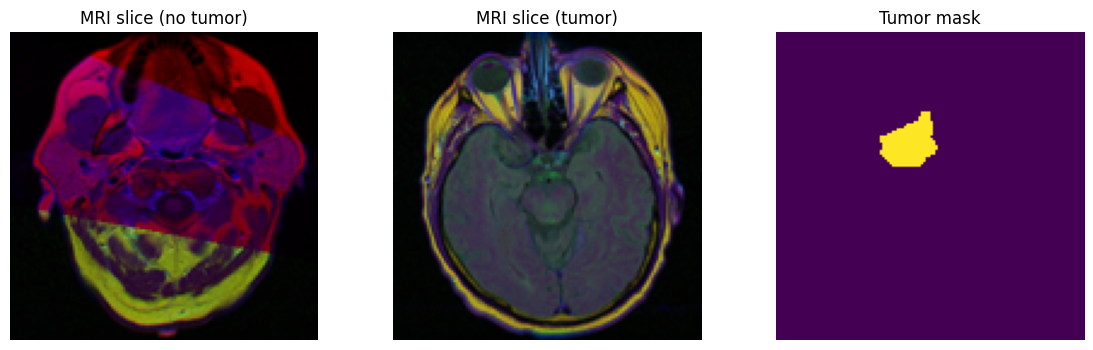

In [5]:
import glob, numpy as np, matplotlib.pyplot as plt
from PIL import Image

imgs = sorted(glob.glob(DRIVE + '/brain/images/*.png'))
msks = sorted(glob.glob(DRIVE + '/brain/masks/*.png'))

# Find a tumor example (non-zero mask)
tumor_idx = next(i for i,m in enumerate(msks)
                 if np.array(Image.open(m)).max() > 0)

fig = plt.figure(figsize=(14, 4))
titles = ['MRI slice (no tumor)', 'MRI slice (tumor)', 'Tumor mask']
imgs_show = [imgs[0], imgs[tumor_idx], msks[tumor_idx]]
for k, (t, p) in enumerate(zip(titles, imgs_show)):
    ax = fig.add_subplot(1, 3, k+1)
    ax.imshow(np.array(Image.open(p)))
    ax.set_title(t); ax.axis('off')

## 6. Done

In [6]:
import glob
n_img = len(glob.glob(DRIVE + '/brain/images/*.png'))
n_msk = len(glob.glob(DRIVE + '/brain/masks/*.png'))
print('Setup complete ✓')
print(f'  {n_img} images saved to Drive')
print(f'  {n_msk} masks  saved to Drive')
print()
print('Next step: run 01_train_test.ipynb')

Setup complete ✓
  3929 images saved to Drive
  3929 masks  saved to Drive

Next step: run 01_train_test.ipynb
